In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager

font_dir = Path("/Users/sophiazhang/anaconda3/envs/shuoz/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf")
font_paths = [
    font_dir / "Myriad Pro Regular.ttf",
    font_dir / "Myriad Pro Bold.ttf",
    font_dir / "MYRIADPRO-SEMIBOLD.OTF"
]

for path in font_paths:
    font_manager.fontManager.addfont(str(path))

plt.rcParams["font.family"] = "Myriad Pro"

fs=16
fss=14

RESULTS_DIR = Path("./results/robustness_DP_ICT")

In [ ]:
# baseline
df_base = pd.read_csv("./results/digital_consumption_metrics_2000_2020.csv")
# ICT robustness
df_ict = pd.read_csv("./results/robustness_DP_ICT/robustness_ICT_only_results.csv")

In [8]:
def interpolate_years(df, year_col="year"):
    df = df.copy()
    df = df.sort_values(year_col)
    df[year_col] = df[year_col].astype(int)
    df = df.set_index(year_col)
    full_years = np.arange(df.index.min(), df.index.max() + 1)
    df = df.reindex(full_years)
    # 仅对数值列插值
    num_cols = df.select_dtypes(include=[np.number]).columns
    df[num_cols] = df[num_cols].interpolate(method="linear", limit_direction="both")
    df = df.reset_index().rename(columns={"index": year_col})
    return df

In [11]:
# baseline
df_base_interp = interpolate_years(df_base)
# ICT robustness
df_ict_interp = interpolate_years(df_ict)
years = df_base_interp["year"].astype(int)

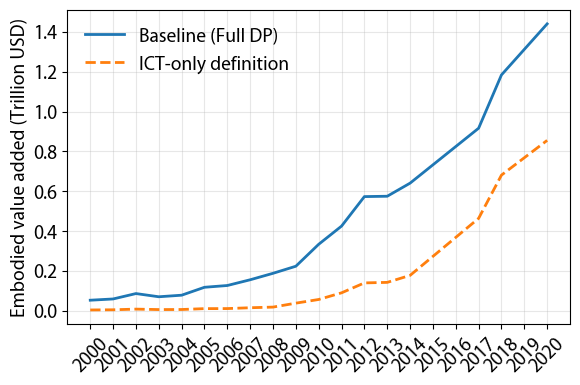

In [23]:
fig, ax = plt.subplots(figsize=(6,4), facecolor="none")
ax.plot(years, df_base_interp["DP_TotalEffect"]/1e6,
        label="Baseline (Full DP)", linewidth=2)
ax.plot(years, df_ict_interp["DP_ICT_TotalEffect"]/1e6,
        label="ICT-only definition", linestyle="--", linewidth=2)

ax.set_ylabel("Embodied value added (Trillion USD)", fontsize=fss)
# ax.set_title("Robustness of Digital Contribution under Alternative DP Definition")
ax.set_xticks(years)
ax.set_xticklabels(years.astype(int), fontsize=fss, rotation=45)
ax.tick_params(labelsize=fss)
ax.legend(fontsize=fss, frameon=False)
ax.grid(alpha=0.3)
ax.set_facecolor('none')

fig.tight_layout()
fig.savefig("./results/robustness_DP_ICT/fig1_total_effect_comparison.png", dpi=300)
plt.show()

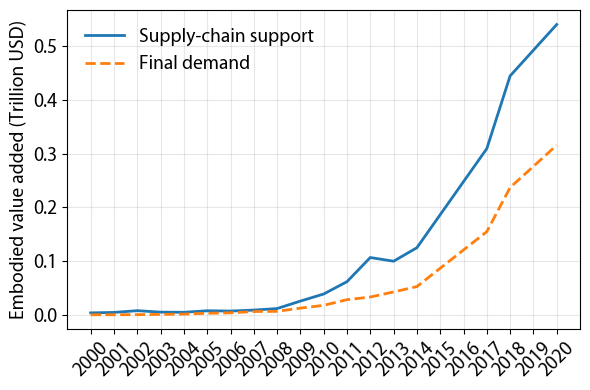

In [24]:
fig, ax = plt.subplots(figsize=(6,4), facecolor="none")
ax.plot(years, df_ict_interp["DP_ICT_Support"]/1e6,
        label="Supply-chain support", linewidth=2)

ax.plot(years, df_ict_interp["DP_ICT_FinalDemand"]/1e6,
        label="Final demand", linestyle="--", linewidth=2)

ax.set_ylabel("Embodied value added (Trillion USD)", fontsize=fss)
# ax.set_title("Decomposition under ICT-only Definition", fontsize=fs)
ax.set_xticks(years)
ax.set_xticklabels(years.astype(int), fontsize=fss, rotation=45)
ax.tick_params(axis="y", labelsize=fss)
ax.legend(fontsize=fss, frameon=False)
ax.set_facecolor("none")
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig("./results/robustness_DP_ICT/fig2_ICT_decomposition.png", dpi=300)
plt.show()

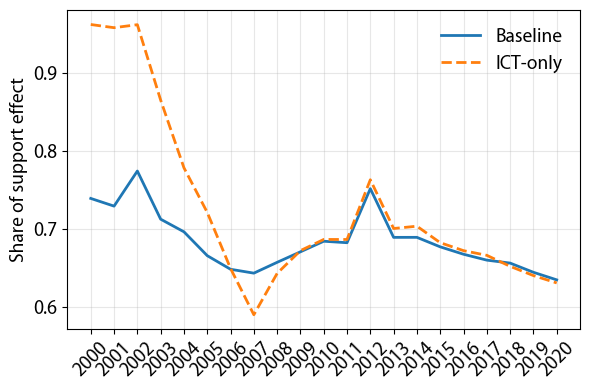

In [25]:
df_base_interp["support_ratio_base"] = df_base_interp["DP_Support"] / df_base_interp["DP_TotalEffect"]
df_ict_interp["support_ratio_ict"] = df_ict_interp["DP_ICT_Support"] / df_ict_interp["DP_ICT_TotalEffect"]

fig, ax = plt.subplots(figsize=(6,4))

ax.plot(years, df_base_interp["support_ratio_base"],
        label="Baseline", linewidth=2)

ax.plot(years, df_ict_interp["support_ratio_ict"],
        label="ICT-only", linestyle="--", linewidth=2)

ax.set_ylabel("Share of support effect", fontsize=fss)
# ax.set_title("Stability of Supply-chain Channel Dominance", fontsize=fss)
ax.set_xticks(years)
ax.set_xticklabels(years.astype(int), fontsize=fss, rotation=45)
ax.tick_params(axis="y", labelsize=fss)
ax.legend(fontsize=fss, frameon=False)
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig("./results/robustness_DP_ICT/fig3_support_ratio.png", dpi=300)
plt.show()